# Credit Default Prediction & Explainable AI

### Machine Learning Classification, Model Evaluation and SHAP Explainability

This project develops an end-to-end machine learning pipeline to predict credit card default risk using financial and demographic customer data.

The analysis is based on the **Default of Credit Card Clients** dataset from the UCI Machine Learning Repository, containing information from 30,000 credit card customers.

The project covers:

- Exploratory Data Analysis (EDA)
- Data cleaning and preprocessing
- Imbalanced classification
- Logistic Regression
- Random Forest
- Gradient Boosting
- Model comparison using ROC-AUC and F1-score
- Global model explainability with SHAP
- Local prediction explainability with SHAP
- Critical evaluation of model limitations

The objective is not only to maximize predictive performance, but also to understand **why the model makes its predictions**, an essential requirement when applying machine learning to financial risk assessment.

In [ ]:
# =========================
# IMPORTACIÓN DE LIBRERÍAS
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

import shap

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## 1. Dataset and Data Preparation

The dataset contains demographic information, credit limits, payment history, bill statements and previous payment amounts for **30,000 credit card customers**.

The target variable indicates whether each customer defaulted on their payment in the following month.

Before model development, the dataset is inspected and cleaned to ensure consistent categorical values and remove variables without predictive relevance.

In [ ]:
# =========================
# CARGA DEL DATASET
# =========================

# Cargar archivo Excel
df = pd.read_excel("default of credit card clients.xls", header=1)

# Mostrar dimensiones
print("Dimensiones del dataset:", df.shape)

# Mostrar primeras filas
df.head()

Dimensiones del dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 1.1 Data Inspection

The dataset is first inspected to identify its dimensionality, data types, missing values and target distribution.

This initial inspection helps detect potential data quality issues before preprocessing and model development.

In [ ]:
# =========================
# INFORMACIÓN GENERAL
# =========================

df.info()

print("\nValores nulos:")
print(df.isnull().sum())

print("\nDistribución variable objetivo:")
print(df["default payment next month"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

### 1.2 Data Cleaning

Categorical inconsistencies are corrected before training the models.

The target variable is renamed for convenience, the identifier column is removed because it does not provide predictive information, and anomalous category values in `EDUCATION` and `MARRIAGE` are grouped into their corresponding "other" categories.

In [ ]:
# =========================
# LIMPIEZA Y PREPARACIÓN
# =========================

# Renombrar variable objetivo para mayor comodidad
df.rename(columns={"default payment next month": "default"}, inplace=True)

# Eliminar columna ID (no aporta valor predictivo)
df.drop("ID", axis=1, inplace=True)

# Revisar valores únicos antes de limpiar
print("Valores EDUCATION:")
print(sorted(df["EDUCATION"].unique()))

print("\nValores MARRIAGE:")
print(sorted(df["MARRIAGE"].unique()))

Valores EDUCATION:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Valores MARRIAGE:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [ ]:
# =========================
# TRATAMIENTO DE VALORES ANÓMALOS
# =========================

# EDUCATION:
# 0, 5 y 6 se agrupan como 4 (otros)
df["EDUCATION"] = df["EDUCATION"].replace([0, 5, 6], 4)

# MARRIAGE:
# 0 se agrupa como 3 (otros)
df["MARRIAGE"] = df["MARRIAGE"].replace(0, 3)

# Comprobar resultado
print("Valores EDUCATION corregidos:")
print(sorted(df["EDUCATION"].unique()))

print("\nValores MARRIAGE corregidos:")
print(sorted(df["MARRIAGE"].unique()))

Valores EDUCATION corregidos:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Valores MARRIAGE corregidos:
[np.int64(1), np.int64(2), np.int64(3)]


## 2. Exploratory Data Analysis

Exploratory analysis is performed to understand the demographic and financial characteristics of the customers and identify potential relationships with credit default.

Particular attention is given to the target distribution because default prediction is an imbalanced classification problem.

### 2.1 Credit Limit Distribution

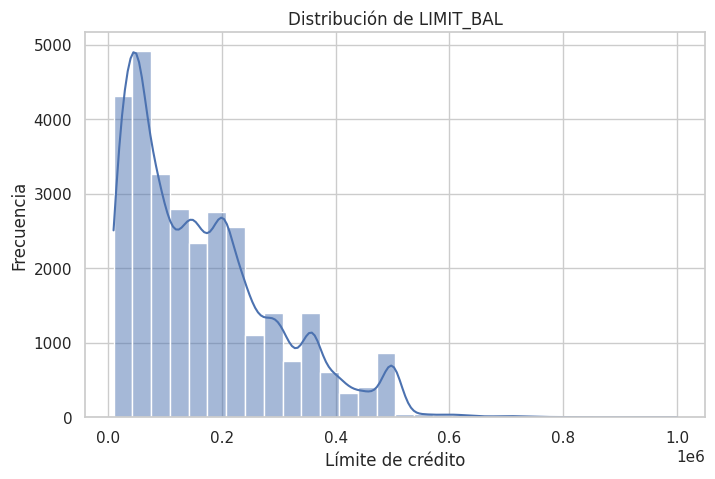

In [ ]:
# =========================
# DISTRIBUCIÓN DE LIMIT_BAL
# =========================

plt.figure(figsize=(8,5))

sns.histplot(df["LIMIT_BAL"], bins=30, kde=True)

plt.title("Distribución de LIMIT_BAL")
plt.xlabel("Límite de crédito")
plt.ylabel("Frecuencia")

plt.show()

La variable LIMIT_BAL presenta una distribución sesgada hacia valores bajos y medios, con una concentración importante de clientes en límites inferiores a 300.000 NT$. También se observan algunos valores extremos altos, lo que indica presencia de outliers. La distribución no es normal y muestra una cola larga hacia la derecha. Esto sugiere una gran variabilidad en la capacidad crediticia de los clientes.

### 2.2 Customer Age Distribution

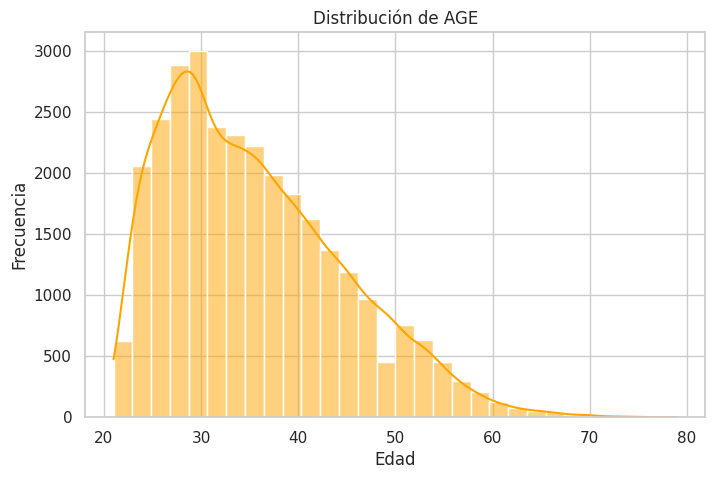

In [ ]:
# =========================
# DISTRIBUCIÓN DE AGE
# =========================

plt.figure(figsize=(8,5))

sns.histplot(df["AGE"], bins=30, kde=True, color="orange")

plt.title("Distribución de AGE")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

La mayoría de los clientes tienen edades comprendidas entre 25 y 40 años. La distribución es relativamente estable y presenta menos dispersión que LIMIT_BAL. Se observa una ligera asimetría hacia edades más altas, aunque sin presencia clara de valores atípicos extremos.

### 2.3 Target Class Distribution

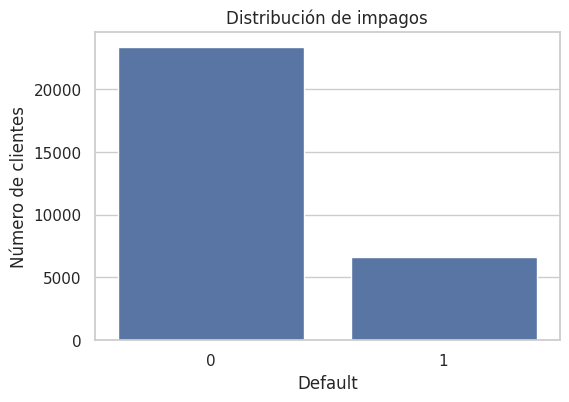

default
0    77.88
1    22.12
Name: proportion, dtype: float64


In [ ]:
# =========================
# DISTRIBUCIÓN DEL TARGET
# =========================

plt.figure(figsize=(6,4))

sns.countplot(x="default", data=df)

plt.title("Distribución de impagos")
plt.xlabel("Default")
plt.ylabel("Número de clientes")

plt.show()

# Porcentajes
print(df["default"].value_counts(normalize=True) * 100)

Existe un claro desbalance en la variable objetivo. La mayoría de los clientes pertenecen a la clase 0 (no impago), mientras que la clase 1 representa una proporción considerablemente menor. Este desbalance puede afectar negativamente al rendimiento del modelo sobre la clase minoritaria, especialmente en métricas como recall o F1-score.

### 2.4 Credit Limit and Default Risk

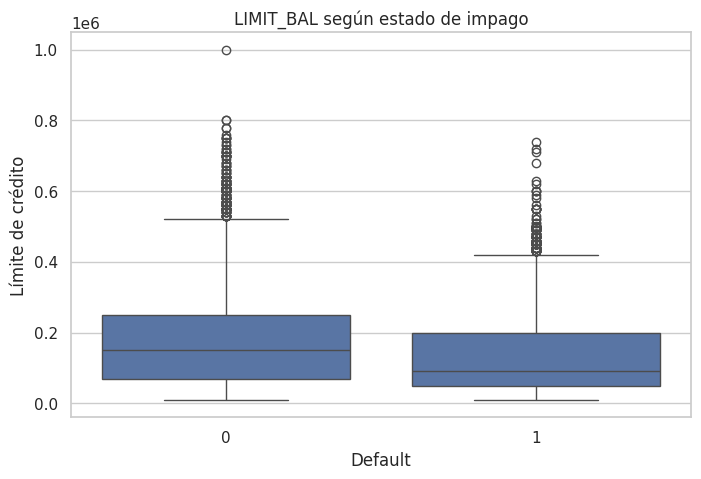

In [ ]:
# =========================
# RELACIÓN LIMIT_BAL Y DEFAULT
# =========================

plt.figure(figsize=(8,5))

sns.boxplot(x="default", y="LIMIT_BAL", data=df)

plt.title("LIMIT_BAL según estado de impago")
plt.xlabel("Default")
plt.ylabel("Límite de crédito")

plt.show()

Los clientes que incurrieron en impago suelen presentar límites de crédito más bajos en comparación con aquellos que no impagaron. Además, el grupo sin impago muestra una mayor dispersión y presencia de valores altos. Esto sugiere que el límite de crédito podría ser una variable relevante para predecir el riesgo de default.

## 3. Model Development and Evaluation

The dataset is divided into training and test sets using an 80/20 split.

Three supervised classification algorithms are compared:

- Logistic Regression
- Random Forest
- Gradient Boosting

Since the target variable is imbalanced, model selection is based not only on overall performance but particularly on **ROC-AUC and F1-score for the default class**.

In [ ]:
# =========================
# SEPARACIÓN DE VARIABLES
# =========================

X = df.drop("default", axis=1)
y = df["default"]

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (24000, 23)
Test: (6000, 23)


### 3.1 Model Training

Logistic Regression provides a linear baseline, while Random Forest and Gradient Boosting introduce non-linear ensemble approaches capable of capturing more complex relationships in customer financial behavior.

In [ ]:
# =========================
# ENTRENAMIENTO DE MODELOS
# =========================

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

gb_model = GradientBoostingClassifier(
    random_state=42
)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Modelos entrenados correctamente")

Modelos entrenados correctamente


### 3.2 Model Evaluation

Each model is evaluated on the held-out test set using classification metrics and ROC-AUC.

Special attention is given to performance on **defaulting customers (class 1)**, since this is the minority and business-critical class.

In [ ]:
# =========================
# EVALUACIÓN DE MODELOS
# =========================

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

results = []

for name, model in models.items():

    # Predicciones
    y_pred = model.predict(X_test)

    # Probabilidades para AUC
    y_proba = model.predict_proba(X_test)[:, 1]

    # Métricas
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    auc = roc_auc_score(y_test, y_proba)

    f1_default = report["1"]["f1-score"]

    results.append({
        "Modelo": name,
        "AUC": round(auc, 4),
        "F1-score clase 1": round(f1_default, 4)
    })

    print("="*50)
    print(name)
    print("="*50)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    print(f"AUC: {auc:.4f}")

Logistic Regression

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000

AUC: 0.7079
Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000

AUC: 0.7572
Gradient Boosting

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                   

### 3.3 Model Comparison

The tree-based models outperform Logistic Regression, suggesting that credit default risk depends on non-linear interactions between financial variables.

**Gradient Boosting achieves the best overall balance:**

| Model | ROC-AUC | F1-score — Default |
|---|---:|---:|
| Logistic Regression | 0.7079 | 0.36 |
| Random Forest | 0.7572 | 0.46 |
| **Gradient Boosting** | **0.7790** | **0.47** |

Gradient Boosting is therefore selected as the final model for the explainability analysis.

## 4. Model Explainability with SHAP

Predictive performance alone is not sufficient in a financial risk application. It is also important to understand which variables drive model decisions.

SHAP (SHapley Additive exPlanations) is applied to the selected Gradient Boosting model to provide both:

- **Global explanations**, identifying the variables that influence the model most.
- **Local explanations**, showing why the model produces a specific prediction for an individual customer.

In [ ]:
# =========================
# EXPLICABILIDAD CON SHAP
# =========================

# Crear explainer
explainer = shap.Explainer(gb_model)

# Tomar subconjunto de test
X_test_sample = X_test.iloc[:500]

# Calcular valores SHAP
shap_values = explainer(X_test_sample)

print("Valores SHAP calculados correctamente")

Valores SHAP calculados correctamente


### 4.1 Global Feature Impact — SHAP Summary Plot

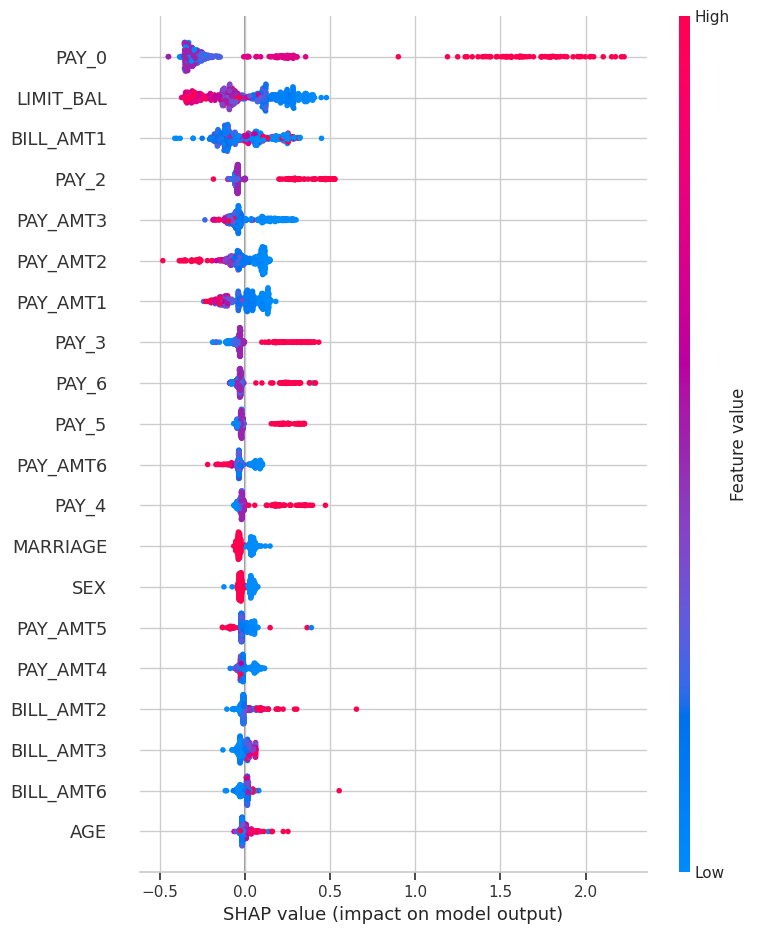

In [ ]:
# =========================
# SUMMARY PLOT
# =========================

shap.summary_plot(
    shap_values,
    X_test_sample
)

The SHAP summary plot shows that recent payment behavior is the strongest driver of credit default predictions.

`PAY_0` is the most influential variable, followed by features such as `LIMIT_BAL`, `BILL_AMT1` and `PAY_2`.

Recent payment delays generally increase the predicted risk of default, while higher credit limits tend to be associated with lower predicted risk.

### 4.2 Local Explainability — SHAP Waterfall Plot

A SHAP waterfall plot is used to explain the prediction for an individual customer.

The visualization shows how each feature moves the prediction away from the model's baseline prediction, making it possible to understand the contribution of individual financial characteristics.

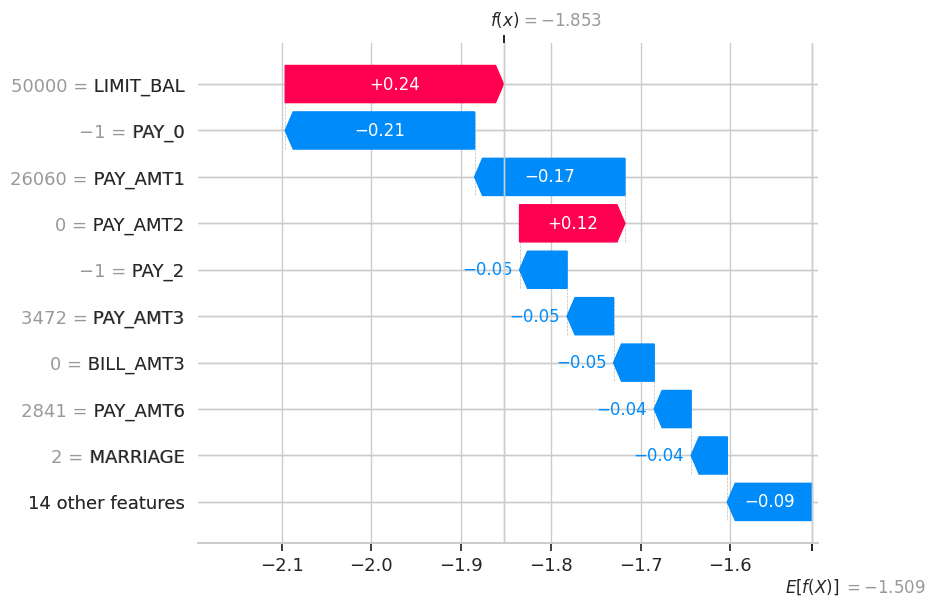

In [ ]:
# =========================
# WATERFALL PLOT
# =========================

# Elegimos una observación concreta
idx = 0

shap.plots.waterfall(shap_values[idx])

El waterfall_plot permite analizar de forma individual cómo cada variable influye en la predicción de un cliente concreto.

En este caso, LIMIT_BAL es la variable que más incrementa el riesgo estimado de impago, sugiriendo que el límite de crédito del cliente contribuye negativamente a su perfil financiero.

Sin embargo, variables como PAY_0 y PAY_AMT1 reducen parcialmente dicho riesgo, indicando un comportamiento de pago relativamente más favorable en algunos periodos recientes.

También se observa que PAY_AMT2 aumenta ligeramente la probabilidad de default, mientras que otras variables tienen un impacto menor sobre la predicción final.

La combinación de todos estos factores lleva al modelo a generar una predicción final concreta para el cliente analizado, mostrando de manera transparente cómo se construye la decisión automática.

### 4.3 Global Feature Importance

The SHAP bar plot provides an aggregated ranking of feature importance across the analyzed customers, complementing the information provided by the summary plot.

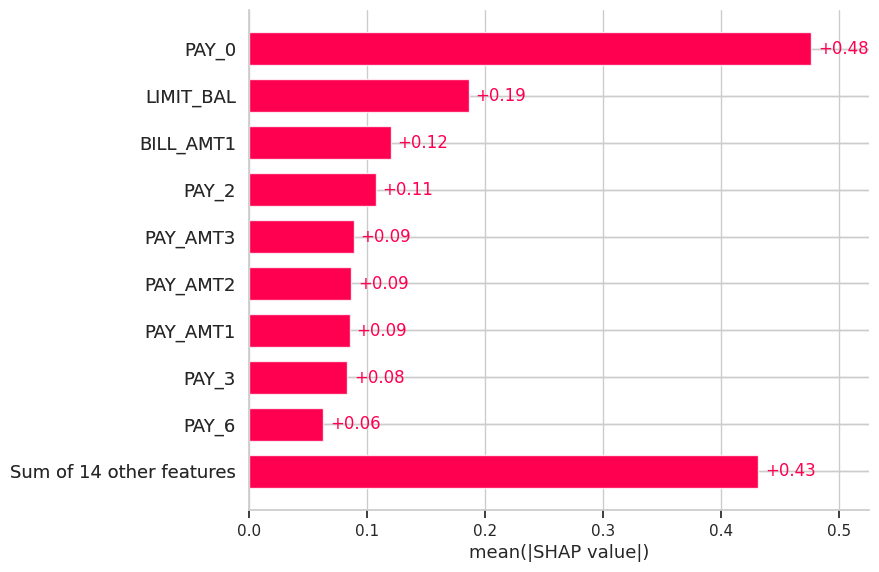

In [ ]:
# =========================
# BAR PLOT DE IMPORTANCIA
# =========================

shap.plots.bar(shap_values)

El gráfico de barras confirma la importancia global de las variables identificadas anteriormente, destacando especialmente el peso del historial de pagos recientes en la toma de decisiones del modelo.

## 5. Final Model Analysis

The confusion matrix of the selected Gradient Boosting model is analyzed to assess its behavior on both non-defaulting and defaulting customers.

This is particularly relevant because a model can achieve high overall accuracy while still failing to detect a substantial proportion of customers who eventually default.

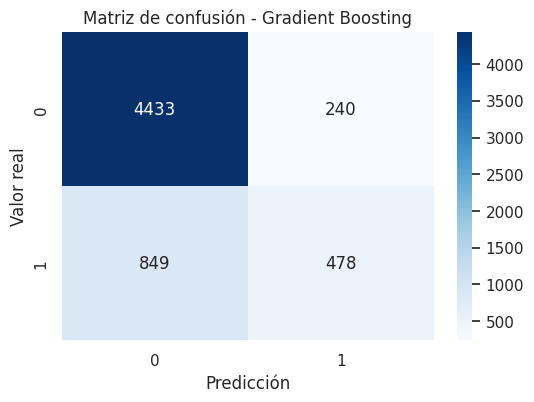

In [ ]:
# =========================
# MATRIZ DE CONFUSIÓN DEL MEJOR MODELO
# =========================

y_pred_gb = gb_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de confusión - Gradient Boosting")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

## 5.1 Limitations and Potential Improvements

El modelo seleccionado, Gradient Boosting, obtiene un rendimiento general razonable, con una accuracy de 0.82 y un AUC de 0.7790. Esto indica que el modelo tiene una capacidad aceptable para distinguir entre clientes que impagan y clientes que no impagan. Sin embargo, al analizar la clase minoritaria, correspondiente a los clientes con default, se observa una limitación importante: el recall es de 0.36 y el F1-score de 0.47. Esto significa que el modelo identifica correctamente solo una parte de los clientes que realmente impagan.

Esta limitación es relevante en un contexto financiero, ya que no detectar clientes con alto riesgo puede generar pérdidas económicas para la entidad. El problema está relacionado principalmente con el desbalance de clases, ya que la mayoría de clientes pertenecen a la clase 0, lo que favorece que el modelo aprenda mejor el patrón de los clientes que no impagan.

Para mejorar el rendimiento, se podrían aplicar técnicas de balanceo como SMOTE o undersampling, con el objetivo de mejorar la detección de la clase minoritaria. También sería recomendable ajustar el umbral de decisión, reduciéndolo por debajo de 0.5 para aumentar el recall de la clase default. Otra mejora posible sería entrenar modelos con penalización de clases o probar algoritmos más avanzados como XGBoost o LightGBM.

En conclusión, el modelo es útil como primera aproximación al scoring de riesgo, pero debería optimizarse antes de ser utilizado en un entorno financiero real.

## 6. Conclusions

This project demonstrates an end-to-end machine learning workflow for credit default prediction, combining data exploration, model comparison and explainable AI.

Among the evaluated algorithms, **Gradient Boosting provided the best trade-off between discrimination capability and minority-class performance**, achieving a ROC-AUC of **0.7790** and an F1-score of **0.47** for defaulting customers.

The SHAP analysis showed that recent payment behavior is one of the strongest drivers of model predictions, particularly variables such as `PAY_0`, while credit-related variables such as `LIMIT_BAL` also play an important role.

However, the relatively limited detection performance for the minority class highlights the importance of addressing class imbalance and decision thresholds in financial risk applications.

Overall, the project illustrates why model performance and model explainability should be evaluated together when machine learning systems are used to support high-impact financial decisions.